In [ ]:
import polars as pl
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# --- 1. Configuration & Data Loading ---
k_clusters = 512                            # 512 is usually the sweetspot
model_name = "qwen3-8b-with-instruction"    # qwen3-with-instruction is best

dat = pl.read_parquet(f"../../data/clustered_embeddings/{model_name}/autoencoded_clusters_{k_clusters}.parquet")

# --- 2. Filtering & Splitting ---
# Shuffle the dataframe so related items arent near one another (avoid distribution leaks)
dat = (
    dat.sample(fraction=1.0, seed=42)
    # Drop nulls in 'r' and perfect correlations
    .filter((pl.col("r").is_not_null()) & (pl.col("r") != 1))  
)
dat.shape

(120653, 1061)

In [59]:
# --- XGBOOST MODEL TRAINING & VALIDATION ---
# This chunk handles the final training pipeline, including feature weighting,
# categorical pooling, and GPU-accelerated regression.

# ---- 1. INITIAL SPLIT ----
# 90/10 split for training and holdout validation
train_df = dat.sample(fraction=0.8, seed=42)
test_df = dat.join(train_df, on=dat.columns, how="anti")

# ---- 2. IMPORTANCE WEIGHTS & PREPROCESSING ----
# Apply exponential weighting to the target 'r' to prioritize high-correlations
train_weights = train_df.select(
    #(pl.col("r").abs() * 8).exp().alias("weight")
).to_numpy().flatten()

# Group features: nominal (sentiment/emotion) vs. numeric (embeddings/similarity)
nominal_cols = [
    "top_sentiment_item1", "top_emotion_item1",
    "top_sentiment_item2", "top_emotion_item2"
]
numeric_cols = [c for c in train_df.columns if train_df[c].dtype.is_numeric() and not c == 'r']

# --- 3. CATEGORICAL POOLING (STEP_OTHER) ---
# Pool rare emotion/sentiment labels (threshold < 5%) into an 'other' category 
# to prevent over-fitting on sparse classes and stabilize the OneHotEncoder.

# --- 4. ENCODING & SCALING ---
# Standardize numeric ranges and expand categories into binary dummy variables.
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
scaler = StandardScaler()

# Fit/Transform Training Data
X_train_num = scaler.fit_transform(train_df.select(numeric_cols).to_numpy())
X_train_cat = encoder.fit_transform(train_df.select(nominal_cols).to_numpy())
X_train = np.hstack([X_train_num, X_train_cat])
y_train = train_df.select("r").to_numpy().flatten()

# Transform Testing Data
X_test_num = scaler.transform(test_df.select(numeric_cols).to_numpy())
X_test_cat = encoder.transform(test_df.select(nominal_cols).to_numpy())
X_test = np.hstack([X_test_num, X_test_cat])
y_test = test_df.select("r").to_numpy().flatten()

# --- 5. XGBOOST CONFIGURATION & TRAINING ---
# Optimized for GPU execution (CUDA) using the histogram-based tree method.
xgb_spec = {
    'n_estimators': 1000,
    'max_depth': 7,
    'learning_rate': 0.02,
    'gamma': 0.01,                  # Minimum loss reduction for a split
    'subsample': 0.8,           # Row sampling to prevent over-fitting
    'min_child_weight': 5,      # Minimum sum of instance weight in a leaf
    'tree_method': 'hist',
    'device': 'cuda:0',
    'objective': 'reg:squarederror',
    'n_jobs': -1,               # Set to -1 for fast training, uses all available CPU cores for non GPU related tasks
    'eval_metric': ['rmse', 'mae']
}

model = xgb.XGBRegressor(**xgb_spec)

# Training with sample weights and continuous validation against the test set
model.fit(
    X_train, y_train,
    sample_weight=train_weights,
    eval_set=[(X_test, y_test)],
    verbose=100
)

[0]	validation_0-rmse:0.19342	validation_0-mae:0.15164
[100]	validation_0-rmse:0.12821	validation_0-mae:0.09838
[200]	validation_0-rmse:0.11438	validation_0-mae:0.08684
[300]	validation_0-rmse:0.10794	validation_0-mae:0.08156
[400]	validation_0-rmse:0.10389	validation_0-mae:0.07830
[500]	validation_0-rmse:0.10077	validation_0-mae:0.07582
[600]	validation_0-rmse:0.09826	validation_0-mae:0.07380
[700]	validation_0-rmse:0.09607	validation_0-mae:0.07202
[800]	validation_0-rmse:0.09429	validation_0-mae:0.07059
[900]	validation_0-rmse:0.09272	validation_0-mae:0.06930
[999]	validation_0-rmse:0.09128	validation_0-mae:0.06811


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda:0'
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree

In [60]:
# 1. Predict on the Test Set
preds = model.predict(X_test)

# 2. Construct test_results
test_results = test_df.with_columns([
    pl.Series(".pred", preds),
    (pl.col("r") - pl.Series(".pred", preds)).abs().alias("error")
]).sort("error", descending=True)

# 3. Correlation (Pearson r)
correlation = np.corrcoef(test_results["r"], test_results[".pred"])[0, 1]
print(f"Correlation: {correlation:.4f}")

Correlation: 0.8874


In [61]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Extract true correlation values vs. model predictions
y_true = test_results["r"].to_numpy()
y_pred = test_results[".pred"].to_numpy()

# Calculate final error metrics and variance explained (R-squared)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

# Output Final Results
print(f"RMSE: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")
print(f"MAE: {mae:.4f}")

RMSE: 0.0913
R-squared: 0.7811
MAE: 0.0681


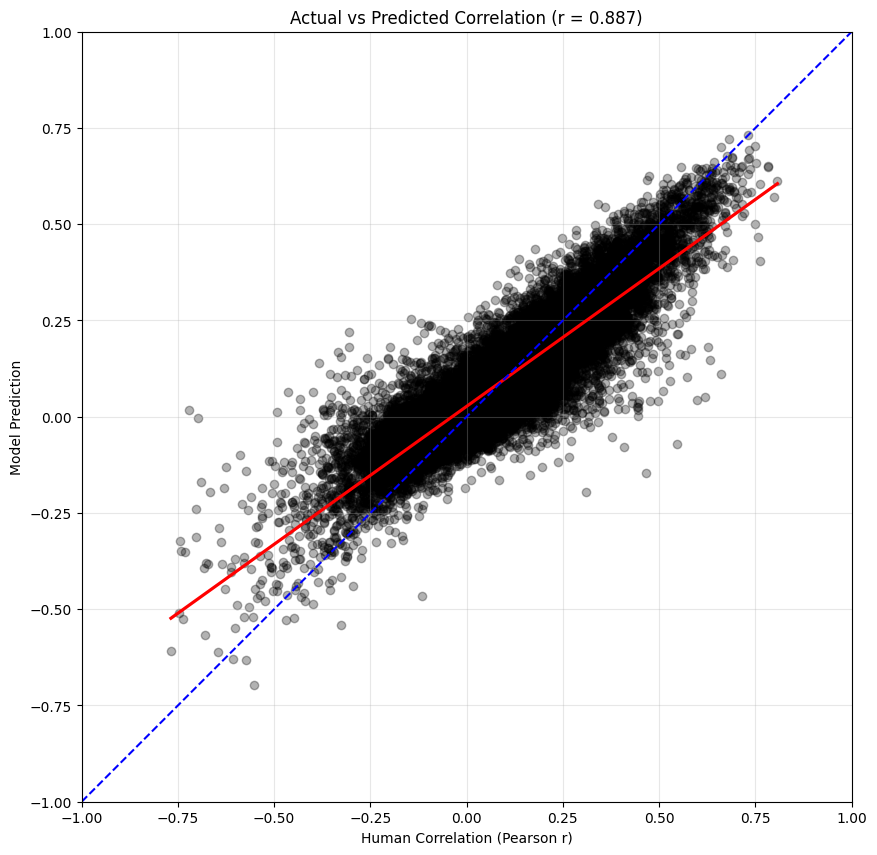

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- VISUAL VALIDATION: ACTUAL VS. PREDICTED ---

plt.figure(figsize=(10, 10))

# Regression plot for correlation density and trendline
sns.regplot(x=y_true, y=y_pred, 
            scatter_kws={'alpha': 0.3, 'color': 'black'}, 
            line_kws={'color': 'red'})

# Identity line for perfect prediction reference (y = x)
plt.plot([-1, 1], [-1, 1], color='blue', linestyle='--')

# Formatting and Axis Constraints
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.gca().set_aspect('equal', adjustable='box')
plt.title(f"Actual vs Predicted Correlation (r = {correlation.round(3)})")
plt.xlabel("Human Correlation (Pearson r)")
plt.ylabel("Model Prediction")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# --- FEATURE IMPORTANCE ---

# Get categorical feature names
cat_feat_names = encoder.get_feature_names_out(nominal_cols).tolist()
numeric_cols = [c for c in train_df.columns if train_df[c].dtype.is_numeric() and not c == 'r']

# Combine names in the exact order of the np.hstack
feat_cols = numeric_cols + cat_feat_names

# Extract gain scores
importances_dict = model.get_booster().get_score(importance_type='gain')

# Map names to f0, f1... indices
importance_data = pl.DataFrame({
    "Feature": feat_cols,
    "Gain": [importances_dict.get(f"f{i}", 0) for i in range(len(feat_cols))]
}).sort("Gain", descending=True)

# Print top 10
print(importance_data.head(10))

# Print bottom 10
print(importance_data.tail(10))

shape: (10, 2)
┌────────────────────┬───────────┐
│ Feature            ┆ Gain      │
│ ---                ┆ ---       │
│ str                ┆ f64       │
╞════════════════════╪═══════════╡
│ global_sim         ┆ 15.339078 │
│ contradiction      ┆ 13.366659 │
│ prod_831           ┆ 8.801519  │
│ thematic_intensity ┆ 8.017353  │
│ pair_positive      ┆ 7.137256  │
│ logical_friction   ┆ 4.305484  │
│ prod_173           ┆ 3.973125  │
│ prod_653           ┆ 3.676975  │
│ prod_413           ┆ 2.763168  │
│ prod_319           ┆ 2.42614   │
└────────────────────┴───────────┘
shape: (10, 2)
┌──────────────────────────────┬──────┐
│ Feature                      ┆ Gain │
│ ---                          ┆ ---  │
│ str                          ┆ f64  │
╞══════════════════════════════╪══════╡
│ top_emotion_item1_disgust    ┆ 0.0  │
│ top_emotion_item1_joy        ┆ 0.0  │
│ top_emotion_item1_sadness    ┆ 0.0  │
│ top_emotion_item1_surprise   ┆ 0.0  │
│ top_sentiment_item2_positive ┆ 0.0  │
│ top_emot

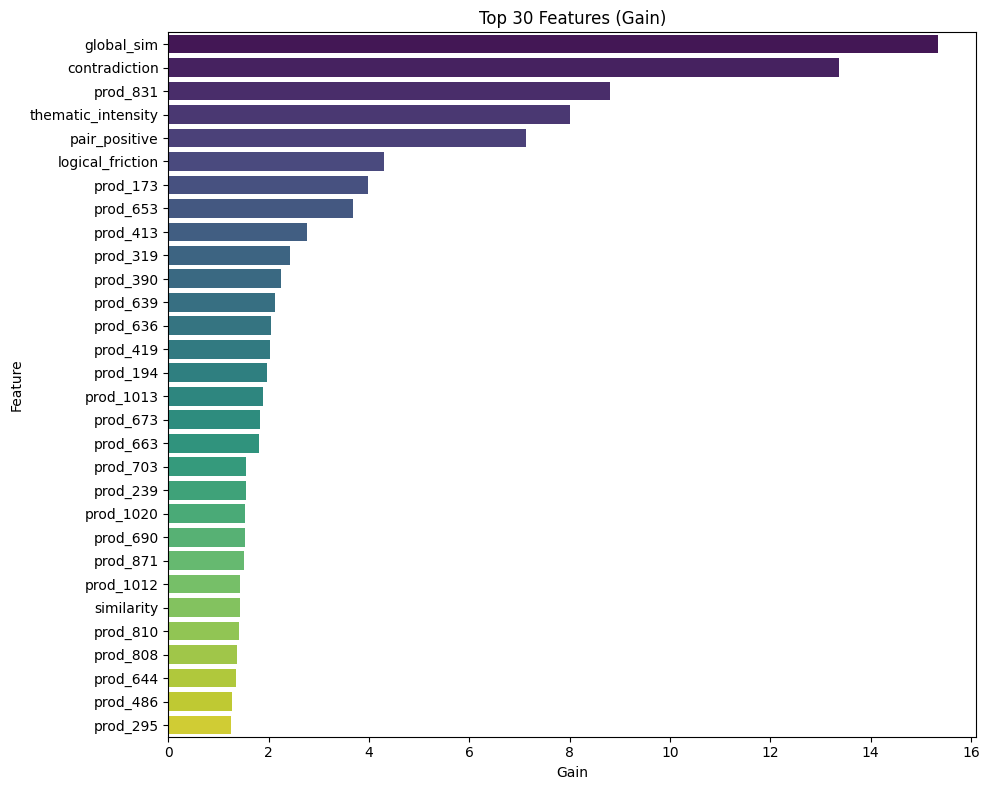

In [64]:
# --- Importance of the Features Plotted ---

plt.figure(figsize=(10, 8))
top_30 = importance_data.head(30).to_pandas()
sns.barplot(data=top_30, x="Gain", y="Feature", palette="viridis", hue="Feature")
plt.title("Top 30 Features (Gain)")
plt.tight_layout()
plt.show()

In [ ]:
# --- CROSS VALIDATION ---

import polars as pl
import polars.selectors as cs
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

# Prepare Groups 
# Group by 'Parameter1'. This ensures all pairs involving a specific 
# item are kept together in either the training set or the validation set.
unique_items = dat.select("Parameter1").unique().sort("Parameter1")
item_to_group = {item: i for i, item in enumerate(unique_items["Parameter1"])}
groups = dat.select("Parameter1").to_series().replace(item_to_group).to_numpy()

# Define feature cols
nominal_cols = [
    "top_sentiment_item1", "top_emotion_item1",
    "top_sentiment_item2", "top_emotion_item2"
]
numeric_cols = [c for c in dat.columns if dat[c].dtype.is_numeric() and c != 'r']

# Initialize Folds and results array
gkf = GroupKFold(n_splits=5)
cv_results = []

print(f"Starting GroupKFold CV (5 Folds) on {len(dat)} pairs...")

# Iterate through the folds
for fold, (train_idx, val_idx) in enumerate(gkf.split(dat, groups=groups)):
    
    # Split Polars Dataframes
    train_df = dat[train_idx]
    val_df = dat[val_idx]    

    # Encode and Scale the features
    scaler = StandardScaler()
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    # Fit on Train, Transform both
    X_train_num = scaler.fit_transform(train_df.select(numeric_cols).to_numpy())
    X_train_cat = encoder.fit_transform(train_df.select(nominal_cols).to_numpy())
    X_train = np.hstack([X_train_num, X_train_cat])
    y_train = train_df.select("r").to_numpy().flatten()

    X_val_num = scaler.transform(val_df.select(numeric_cols).to_numpy())
    X_val_cat = encoder.transform(val_df.select(nominal_cols).to_numpy())
    X_val = np.hstack([X_val_num, X_val_cat])
    y_val = val_df.select("r").to_numpy().flatten()

    # Train XGB model
    model = xgb.XGBRegressor(
        n_estimators=1000,
        max_depth=7,
        learning_rate=0.02,
        gamma=0.01,
        subsample=0.8,
        min_child_weight=5,
        tree_method='hist',
        device='cuda:0',
        early_stopping_rounds=50,
        objective='reg:squarederror'
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False # Set to True to see progress
    )

    # Evaluate
    preds = model.predict(X_val)
    r_val, _ = pearsonr(y_val, preds)
    r2_val = r2_score(y_val, preds)
    
    # Append to results array
    cv_results.append(r_val)
    print(f"Fold {fold+1}: Pearson r = {r_val:.4f} | R² = {r2_val:.4f}")

# Print final Summary
print("-" * 30)
print(f"Mean CV Pearson r: {np.mean(cv_results):.4f} (+/- {np.std(cv_results):.4f})")

Starting GroupKFold CV (5 Folds) on 120653 pairs...
Fold 1: Pearson r = 0.8547 | R² = 0.7250
Fold 2: Pearson r = 0.8600 | R² = 0.7294
Fold 3: Pearson r = 0.8572 | R² = 0.7301
Fold 4: Pearson r = 0.8584 | R² = 0.7308
Fold 5: Pearson r = 0.8572 | R² = 0.7278
------------------------------
Mean CV Pearson r: 0.8575 (+/- 0.0017)
